<a href="https://colab.research.google.com/github/NelvaAdalit/-INTELIGENCIA-ARTIFICIAL-I-/blob/main/OFICIAL_LAB4_1_Sensorless_Drive.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Laboratorio 4 (Parte 1): Regresión Logística One-vs-All (Dataset No Gráfico)

**Estudiante:** Nelva Adalit Mora Barrionuevo

**Dataset:** Sensorless Drive Diagnosis (Clasificación de 11 estados de motores)

**Enlace del Cuadernillo / Github:** https://drive.google.com/file/d/1GRCB9Yo9BWwRg4AbjDqElz9DJl8SzqRt/view?usp=drive_link

**Descripción del Trabajo Realizado:**

En este cuadernillo se implementa desde cero un modelo de Regresión Logística con enfoque One-vs-All (OvA) para resolver un problema de clasificación multiclase. Se utilizó un dataset puramente tabular (no gráfico) que supera ampliamente los requisitos del laboratorio ($m \ge 50000$ y $n \ge 40$).

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# utilizado para la manipulación de directorios y rutas
import os

# Cálculo científico y vectorial para python
import numpy as np

# Libreria para graficos
from matplotlib import pyplot

# Modulo de optimizacion en scipy
from scipy import optimize

# le dice a matplotlib que incruste gráficos en el cuaderno
%matplotlib inline


---

## Bloque 1 — Carga y Validación de Dataset desde Google Drive

La primera etapa de cualquier proyecto de Machine Learning es **obtener y validar los datos**. En este bloque:

- Conectamos a Google Drive para acceder al dataset
- Cargamos el archivo CSV con `np.loadtxt()` (método eficiente recomendado por el instructor)
- Separamos características (X) de etiquetas de clase (y)
- **Validamos que el dataset cumple requisitos mínimos**: m ≥ 50,000 ejemplos y n ≥ 40 características

> **¿Por qué validar dimensiones?** Garantiza que tenemos volumen de datos suficiente para entrenar un modelo robusto. Pocos datos = riesgo de underfitting (el modelo no aprende).

In [ ]:
import pandas as pd

# 1. Cargar datos USANDO PANDAS (Requisito del ingeniero)
df = pd.read_csv('/content/drive/MyDrive/SIS420IA/Sensorless_drive_diagnosis_limpio.csv', header=None)

# 2. Renombrar la última columna como 'Target'
df.rename(columns={df.columns[-1]: 'Target'}, inplace=True)

# CORRECCIÓN CRÍTICA: Mapear etiquetas de 1-11 → 0-10 (Python usa indexación 0-based)
df['Target'] = df['Target'] - 1

# 3. GARANTIZAR EL BALANCEO EXACTO CON PANDAS (Requisito del ingeniero)
# Sabemos que hay 5319 de cada uno, pero demostramos que sabemos programarlo
cantidad_perfecta = 5300
df_balanceado = df.groupby('Target').sample(n=cantidad_perfecta, random_state=42).reset_index(drop=True)

# 4. Mezclar los datos para que el modelo no aprenda en orden
df_balanceado = df_balanceado.sample(frac=1, random_state=42).reset_index(drop=True)

# 5. Separar características (X) y respuestas (y)
X = df_balanceado.iloc[:, :-1].values
y = df_balanceado.iloc[:, -1].values
m, n = X.shape

print(f"Forma del dataset balanceado: {X.shape}")
print(f"Ejemplos totales (m): {m}")
print(f"Características (n): {n}")
print(f"\nDistribución garantizada por Pandas:")
print(df_balanceado['Target'].value_counts().sort_index())
print(f"\n✓ Cumple m >= 50,000: {m >= 50000}")
print(f"✓ Cumple n >= 40: {n >= 40}")

Forma del dataset balanceado: (58300, 48)
Ejemplos totales (m): 58300
Características (n): 48

Distribución garantizada por Pandas:
Target
0     5300
1     5300
2     5300
3     5300
4     5300
5     5300
6     5300
7     5300
8     5300
9     5300
10    5300
Name: count, dtype: int64

✓ Cumple m >= 50,000: True
✓ Cumple n >= 40: True


## Bloque 2 — Exploración y Visualización de Datos Crudos

Antes de aplicar cualquier transformación, es fundamental **entender la estructura y distribución de los datos**:

- Mostramos ejemplos reales (primeras filas) para inspeccionar qué contienen
- Calculamos estadísticas básicas: mínimo, máximo, media, desviación estándar (ANTES de normalizar)
- **Visualizamos la distribución de clases** mediante histogramas

Esto nos permite detectar problemas: clases desbalanceadas, valores atípicos, o características con rango muy diferente.

> **¿Por qué explorar primero?** Si pasamos datos "sucios" al modelo, obtendremos predicciones "sucias". La exploración es la primera línea de defensa contra basura en = basura out.

In [ ]:
print(f"Primeras 5 filas de características (primeras 10 dimensiones):")
for i in range(5):
    print(f"  Fila {i}: {X[i, :10]}... clase={int(y[i])}")

Primeras 5 filas de características (primeras 10 dimensiones):
  Fila 0: [ 1.3944e-05  4.7445e-05 -1.9662e-04 -1.3062e-05  1.2657e-06  1.8273e-04
  4.7721e-02  4.7674e-02  4.7870e-02  1.1207e-01]... clase=6
  Fila 1: [ 1.7835e-07  7.2522e-06  2.8673e-05  3.7530e-07 -3.5777e-06  3.2605e-05
  1.8909e-02  1.8902e-02  1.8873e-02  1.2598e-02]... clase=4
  Fila 2: [-7.1224e-06 -6.0267e-08 -6.9541e-06 -4.5024e-06 -1.4479e-05  4.6878e-06
 -3.3653e-02 -3.3653e-02 -3.3646e-02 -1.9154e-02]... clase=9
  Fila 3: [ 1.6150e-05 -8.1983e-08  4.2760e-04 -2.4221e-06 -5.0088e-05  8.6982e-04
  1.1982e-02  1.1982e-02  1.1555e-02 -2.6227e-02]... clase=0
  Fila 4: [ 1.3011e-06 -1.4438e-05  1.6873e-05  2.5288e-06 -3.7545e-05 -2.2063e-04
  2.3477e-02  2.3492e-02  2.3475e-02  2.6280e-02]... clase=4


In [ ]:
# Estadísticas de características sin normalizar
print(f"\nESTADÍSTICAS SIN NORMALIZAR:")
print(f"  Primera característica - Mín: {X[:, 0].min():.4f}, Máx: {X[:, 0].max():.4f}, Media: {X[:, 0].mean():.4f}")
print(f"  Primera característica - Desviación: {X[:, 0].std():.4f}")
print(f"\nUltima característica - Mín: {X[:, -1].min():.4f}, Máx: {X[:, -1].max():.4f}, Media: {X[:, -1].mean():.4f}")
print(f"  Ultima característica - Desviación: {X[:, -1].std():.4f}")


ESTADÍSTICAS SIN NORMALIZAR:
  Primera característica - Mín: -0.0137, Máx: 0.0058, Media: -0.0000
  Primera característica - Desviación: 0.0001

Ultima característica - Mín: -1.5213, Máx: -1.3371, Media: -1.4977
  Ultima característica - Desviación: 0.0032


In [ ]:
# Distribución de clases
print(f"\nDISTRIBUCIÓN DE CLASES EN DATOS CARGADOS:")
unique_classes, class_counts = np.unique(y.astype(int), return_counts=True)
for cls, count in zip(unique_classes, class_counts):
    percentage = (count / len(y)) * 100
    print(f"  Clase {cls}: {count:6d} ejemplos ({percentage:5.2f}%)")


DISTRIBUCIÓN DE CLASES EN DATOS CARGADOS:
  Clase 0:   5300 ejemplos ( 9.09%)
  Clase 1:   5300 ejemplos ( 9.09%)
  Clase 2:   5300 ejemplos ( 9.09%)
  Clase 3:   5300 ejemplos ( 9.09%)
  Clase 4:   5300 ejemplos ( 9.09%)
  Clase 5:   5300 ejemplos ( 9.09%)
  Clase 6:   5300 ejemplos ( 9.09%)
  Clase 7:   5300 ejemplos ( 9.09%)
  Clase 8:   5300 ejemplos ( 9.09%)
  Clase 9:   5300 ejemplos ( 9.09%)
  Clase 10:   5300 ejemplos ( 9.09%)


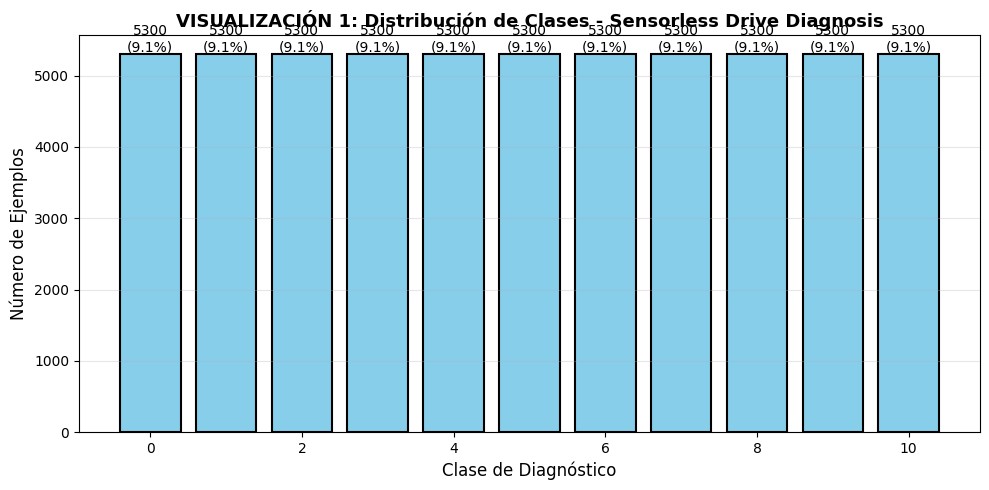

In [ ]:
# Gráfica de distribución de clases
fig, ax = pyplot.subplots(1, 1, figsize=(10, 5))
ax.bar(unique_classes, class_counts, color='skyblue', edgecolor='black', linewidth=1.5)
ax.set_xlabel('Clase de Diagnóstico', fontsize=12)
ax.set_ylabel('Número de Ejemplos', fontsize=12)
ax.set_title('VISUALIZACIÓN 1: Distribución de Clases - Sensorless Drive Diagnosis', fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')
for i, count in enumerate(class_counts):
    percentage = (count / np.sum(class_counts)) * 100
    ax.text(unique_classes[i], count, f'{count}\n({percentage:.1f}%)', ha='center', va='bottom', fontsize=10)
pyplot.tight_layout()
pyplot.show()

## Bloque 3 — Normalización Z-Score (Estandarización de Características)

**La normalización es crítica en Machine Learning.** Aplicamos transformación Z-score:

$$X_{norm} = \frac{X - \mu}{\sigma}$$

Donde:
- μ = media de la característica
- σ = desviación estándar

**¿Por qué normalizar?**
1. **Velocidad de convergencia**: Sin normalización, características con valores grandes dominan el cálculo del gradiente, ralentizando el aprendizaje
2. **Fairness**: Todas las características contribuyen equitativamente al modelo
3. **Estabilidad numérica**: Evita overflow/underflow en cálculos exponenciales

Visualizamos ANTES/DESPUÉS para evidenciar el cambio.

In [ ]:
def featureNormalize(X):
    X_norm = X.copy()
    mu = np.zeros(X.shape[1])
    sigma = np.zeros(X.shape[1])

    mu = np.mean(X, axis=0)
    sigma = np.std(X, axis=0)
    X_norm = (X - mu) / sigma

    return X_norm, mu, sigma

In [ ]:
# Normalizar
X_norm, mu, sigma = featureNormalize(X)

print("✓ Normalización completada.")
print(f"\nESTADÍSTICAS DESPUÉS DE NORMALIZAR:")
print(f"  Primera característica - Media: {X_norm[:, 0].mean():.6f}, Desviación: {X_norm[:, 0].std():.6f}")
print(f"  Última característica - Media: {X_norm[:, -1].mean():.6f}, Desviación: {X_norm[:, -1].std():.6f}")

✓ Normalización completada.

ESTADÍSTICAS DESPUÉS DE NORMALIZAR:
  Primera característica - Media: 0.000000, Desviación: 1.000000
  Última característica - Media: 0.000000, Desviación: 1.000000


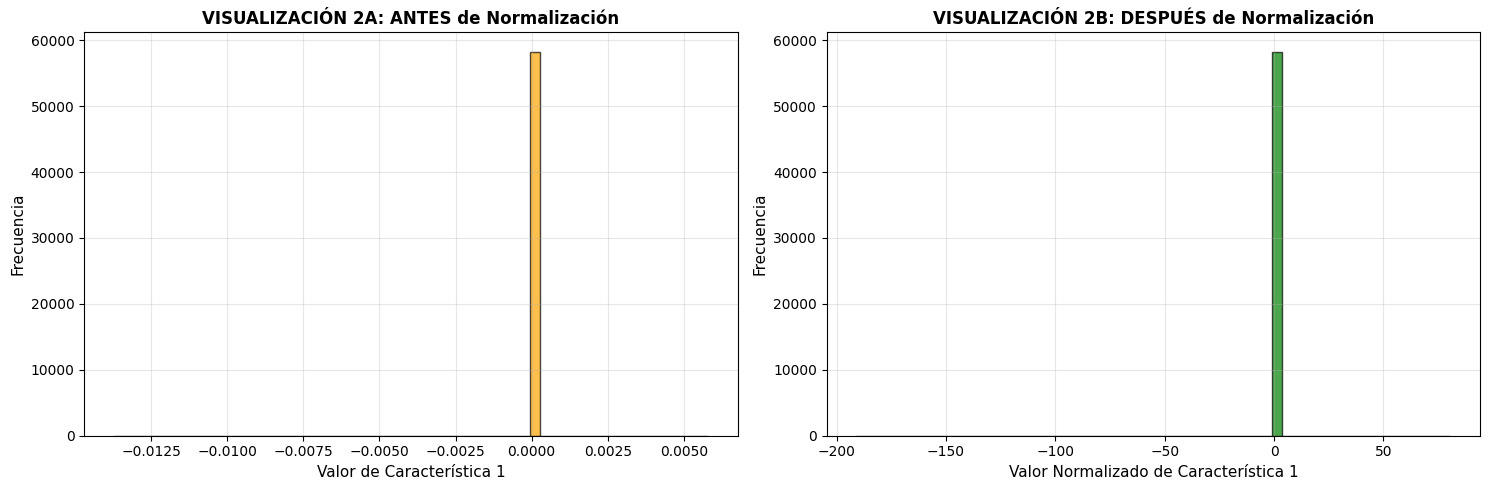

In [ ]:
# Gráfica comparativa: antes y después de normalización
fig, axes = pyplot.subplots(1, 2, figsize=(15, 5))

axes[0].hist(X[:, 0], bins=60, color='orange', alpha=0.7, edgecolor='black')
axes[0].set_xlabel('Valor de Característica 1', fontsize=11)
axes[0].set_ylabel('Frecuencia', fontsize=11)
axes[0].set_title('VISUALIZACIÓN 2A: ANTES de Normalización', fontsize=12, fontweight='bold')
axes[0].grid(True, alpha=0.3)

axes[1].hist(X_norm[:, 0], bins=60, color='green', alpha=0.7, edgecolor='black')
axes[1].set_xlabel('Valor Normalizado de Característica 1', fontsize=11)
axes[1].set_ylabel('Frecuencia', fontsize=11)
axes[1].set_title('VISUALIZACIÓN 2B: DESPUÉS de Normalización', fontsize=12, fontweight='bold')
axes[1].grid(True, alpha=0.3)

pyplot.tight_layout()
pyplot.show()

## Bloque 4 — División 80-20 (Train-Test Split)

**Este es el paso metodológico más importante del laboratorio.** Dividimos datos en dos conjuntos **mutuamente excluyentes**:

- **80% Entrenamiento**: El modelo aprende los parámetros θ SOLO con estos datos
- **20% Prueba**: Se reservan como "datos no vistos" para evaluación honesta

**¿Por qué esta separación es obligatoria?**
Si evaluáramos con los mismos datos del entrenamiento, el modelo podría simplemente "memorizar" las respuestas (overfitting) y lograr 99% de precisión sin haber aprendido nada transferible.

Usamos `np.random.seed(42)` para **reproducibilidad** (NO sklearn, como recomienda el instructor).

> **Concepto clave**: Los datos de prueba son un proxy del "mundo real" que el modelo nunca vio.

In [ ]:
np.random.seed(42)
indices = np.random.permutation(m)

split_point = int(0.8 * m)

train_indices = indices[:split_point]
test_indices = indices[split_point:]

X_train = X_norm[train_indices, :]
y_train = y[train_indices]
X_test = X_norm[test_indices, :]
y_test = y[test_indices]

m_train = X_train.shape[0]
m_test = X_test.shape[0]

print(f"Ejemplos de entrenamiento: {m_train}")
print(f"Ejemplos de prueba: {m_test}")
print(f"Proporción: {m_train}/{m_train+m_test} = {m_train/(m_train+m_test):.1%}")

Ejemplos de entrenamiento: 46640
Ejemplos de prueba: 11660
Proporción: 46640/58300 = 80.0%


In [ ]:
# Distribución de clases en ENTRENAMIENTO y PRUEBA
print(f"\nDISTRIBUCIÓN DE CLASES EN ENTRENAMIENTO:")
train_classes, train_counts = np.unique(y_train.astype(int), return_counts=True)
for cls, count in zip(train_classes, train_counts):
    percentage = (count / len(y_train)) * 100
    print(f"  Clase {cls}: {count:6d} ({percentage:5.2f}%)")

print(f"\nDISTRIBUCIÓN DE CLASES EN PRUEBA:")
test_classes, test_counts = np.unique(y_test.astype(int), return_counts=True)
for cls, count in zip(test_classes, test_counts):
    percentage = (count / len(y_test)) * 100
    print(f"  Clase {cls}: {count:6d} ({percentage:5.2f}%)")


DISTRIBUCIÓN DE CLASES EN ENTRENAMIENTO:
  Clase 0:   4238 ( 9.09%)
  Clase 1:   4278 ( 9.17%)
  Clase 2:   4209 ( 9.02%)
  Clase 3:   4247 ( 9.11%)
  Clase 4:   4240 ( 9.09%)
  Clase 5:   4225 ( 9.06%)
  Clase 6:   4233 ( 9.08%)
  Clase 7:   4268 ( 9.15%)
  Clase 8:   4206 ( 9.02%)
  Clase 9:   4247 ( 9.11%)
  Clase 10:   4249 ( 9.11%)

DISTRIBUCIÓN DE CLASES EN PRUEBA:
  Clase 0:   1062 ( 9.11%)
  Clase 1:   1022 ( 8.77%)
  Clase 2:   1091 ( 9.36%)
  Clase 3:   1053 ( 9.03%)
  Clase 4:   1060 ( 9.09%)
  Clase 5:   1075 ( 9.22%)
  Clase 6:   1067 ( 9.15%)
  Clase 7:   1032 ( 8.85%)
  Clase 8:   1094 ( 9.38%)
  Clase 9:   1053 ( 9.03%)
  Clase 10:   1051 ( 9.01%)


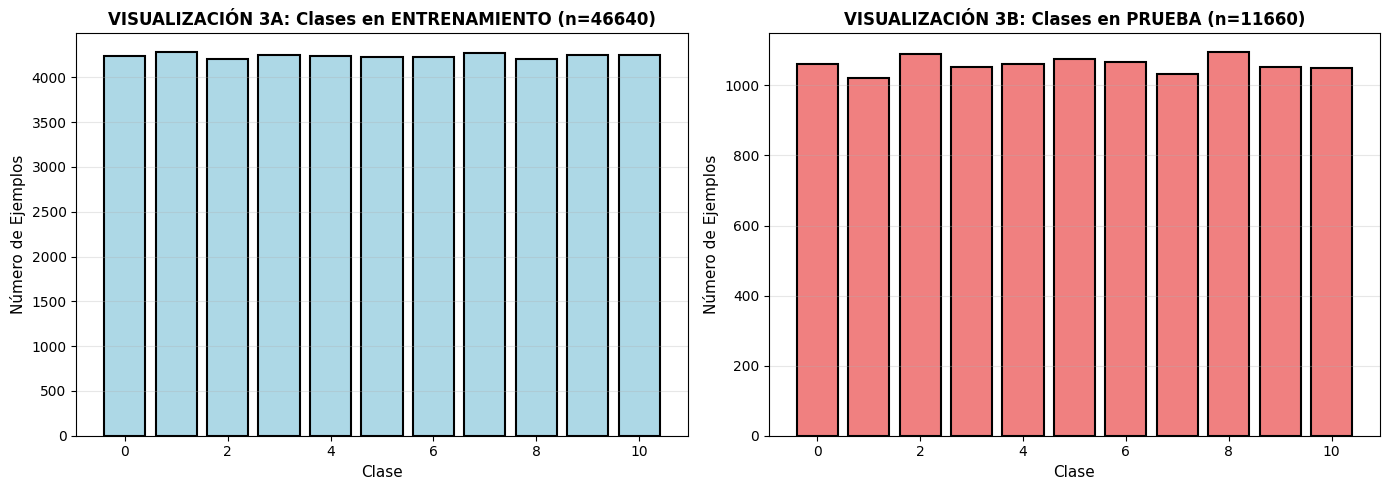

In [ ]:
# Gráfica comparativa de distribución: Train vs Test
fig, axes = pyplot.subplots(1, 2, figsize=(14, 5))

axes[0].bar(train_classes, train_counts, color='lightblue', edgecolor='black', linewidth=1.5)
axes[0].set_xlabel('Clase', fontsize=11)
axes[0].set_ylabel('Número de Ejemplos', fontsize=11)
axes[0].set_title(f'VISUALIZACIÓN 3A: Clases en ENTRENAMIENTO (n={m_train})', fontsize=12, fontweight='bold')
axes[0].grid(True, alpha=0.3, axis='y')

axes[1].bar(test_classes, test_counts, color='lightcoral', edgecolor='black', linewidth=1.5)
axes[1].set_xlabel('Clase', fontsize=11)
axes[1].set_ylabel('Número de Ejemplos', fontsize=11)
axes[1].set_title(f'VISUALIZACIÓN 3B: Clases en PRUEBA (n={m_test})', fontsize=12, fontweight='bold')
axes[1].grid(True, alpha=0.3, axis='y')

pyplot.tight_layout()
pyplot.show()

## Bloque 5 — Función Sigmoide (Núcleo de Regresión Logística)

La función sigmoide es la **función de activación central** de la regresión logística:

$$g(z) = \frac{1}{1 + e^{-z}}$$

**Propiedades críticas:**
- **Salida**: Siempre en rango [0, 1] (probabilidad)
- **Interpretación**: g(z) = P(y=1 | x) = probabilidad de pertenencia a clase positiva
- **Monotonía**: Función estrictamente creciente (si z aumenta, g(z) sube)

**¿Por qué sigmoide y no otra función?**
- Produce probabilidades válidas [0,1]
- Diferenciable (necesario para calcular gradientes)
- Tiene interpretación probabilística clara

In [ ]:
def sigmoid(z):
    z = np.clip(z, -500, 500)
    return 1 / (1 + np.exp(-z))

## Bloque 6 — Función de Costo y Gradiente (Corazón del Aprendizaje)

Implementamos las dos funciones matemáticas que gobiernan el entrenamiento:

### Función de Costo J(θ) — Entropía Cruzada Binaria Regularizada

$$J(\theta) = \frac{1}{m} \sum_{i=1}^m [-y^{(i)}\log(h_\theta(x^{(i)})) - (1-y^{(i)})\log(1-h_\theta(x^{(i)}))] + \frac{\lambda}{2m}\sum_{j=1}^n \theta_j^2$$

Donde:
- **Primer término**: Entropía cruzada (mide error de predicción)
- **Segundo término**: Regularización L2 (penaliza parámetros grandes, previene overfitting)

### Función Gradiente ∇J(θ)

$$\nabla J(\theta) = \frac{1}{m} X^T(h - y) + \frac{\lambda}{m}\theta$$

Indica la dirección de **máximo aumento** del costo. El optimizador se mueve en dirección opuesta para minimizar.

> **¿Por qué regularización L2?** Sin ella, el modelo memoriza datos de entrenamiento. La penalización mantiene parámetros pequeños → modelo más simple → mejor generalización.

In [ ]:
def costFunction(theta, X, y, lambda_reg):
    m = y.size
    h = sigmoid(X.dot(theta))

    h = np.clip(h, 1e-7, 1 - 1e-7)

    J = -(1/m) * (y.dot(np.log(h)) + (1 - y).dot(np.log(1 - h)))

    regularization = (lambda_reg / (2*m)) * np.sum(theta[1:]**2)
    J += regularization

    return J

def gradient(theta, X, y, lambda_reg):
    m = y.size
    h = sigmoid(X.dot(theta))

    grad = (1/m) * X.T.dot(h - y)
    grad[1:] += (lambda_reg/m) * theta[1:]

    return grad

## 7. One-vs-All: Entrenamiento

In [ ]:
num_labels = len(np.unique(y_train.astype(int)))

# Agregar intercepto
X_train_with_intercept = np.column_stack([np.ones(m_train), X_train])
X_test_with_intercept = np.column_stack([np.ones(m_test), X_test])

# Inicializar
all_theta = np.zeros((num_labels, n + 1))

lambda_reg = 1.0

cost_history = {}

print(f"Entrenando {num_labels} clasificadores (One-vs-All)...\n")

for c in range(num_labels):
    y_binary = (y_train == c).astype(int)

    initial_theta = np.zeros(n + 1)

    costs = []

    def cost_wrapper(theta):
        cost = costFunction(theta, X_train_with_intercept, y_binary, lambda_reg)
        costs.append(cost)
        return cost

    def grad_wrapper(theta):
        return gradient(theta, X_train_with_intercept, y_binary, lambda_reg)

    print(f"Clase {c}: ", end="", flush=True)

    result = optimize.minimize(
        cost_wrapper,
        initial_theta,
        method='CG',
        jac=grad_wrapper,
        options={'maxiter': 30}
    )

    all_theta[c] = result.x
    cost_history[c] = costs

    print(f"Costo = {costs[-1]:.6f}, Iteraciones = {len(costs)}")

print("\n✓ Entrenamiento completado.")

Entrenando 11 clasificadores (One-vs-All)...

Clase 0: Costo = 0.057728, Iteraciones = 82
Clase 1: Costo = 0.241940, Iteraciones = 66
Clase 2: Costo = 0.277872, Iteraciones = 67
Clase 3: Costo = 0.195469, Iteraciones = 67
Clase 4: Costo = 0.259653, Iteraciones = 75
Clase 5: Costo = 0.230036, Iteraciones = 71
Clase 6: Costo = 0.003300, Iteraciones = 98
Clase 7: Costo = 0.197306, Iteraciones = 69
Clase 8: Costo = 0.246876, Iteraciones = 62
Clase 9: Costo = 0.171760, Iteraciones = 70
Clase 10: Costo = 0.000207, Iteraciones = 140

✓ Entrenamiento completado.


In [ ]:
print("Realizando predicciones en conjunto de PRUEBA...")
predictions = X_test_with_intercept.dot(all_theta.T)
predicted_classes = np.argmax(predictions, axis=1)

correct = np.sum(predicted_classes == y_test.astype(int))
accuracy = correct / m_test

print(f"\n{'='*60}")
print(f"RESULTADOS DE EVALUACIÓN")
print(f"{'='*60}")
print(f"Exactitud General: {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"Predicciones Correctas: {correct}/{m_test}\n")

Realizando predicciones en conjunto de PRUEBA...

RESULTADOS DE EVALUACIÓN
Exactitud General: 0.7350 (73.50%)
Predicciones Correctas: 8570/11660



In [ ]:
print(f"{'='*60}")
print(f"MÉTRICAS POR CLASE (SIN USAR SKLEARN)")
print(f"{'='*60}\n")

for c in range(num_labels):
    y_test_binary = (y_test.astype(int) == c).astype(int)
    y_pred_binary = (predicted_classes == c).astype(int)

    TP = np.sum((y_pred_binary == 1) & (y_test_binary == 1))
    FP = np.sum((y_pred_binary == 1) & (y_test_binary == 0))
    FN = np.sum((y_pred_binary == 0) & (y_test_binary == 1))
    TN = np.sum((y_pred_binary == 0) & (y_test_binary == 0))

    precision = TP / (TP + FP) if (TP + FP) > 0 else 0
    recall = TP / (TP + FN) if (TP + FN) > 0 else 0
    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

    print(f"Clase {c}:")
    print(f"  Verdaderos Positivos (TP):  {TP:6d}")
    print(f"  Falsos Positivos (FP):      {FP:6d}")
    print(f"  Falsos Negativos (FN):      {FN:6d}")
    print(f"  Verdaderos Negativos (TN):  {TN:6d}")
    print(f"  Precisión: {precision:.4f}")
    print(f"  Recall:    {recall:.4f}")
    print(f"  F1-Score:  {f1:.4f}\n")

MÉTRICAS POR CLASE (SIN USAR SKLEARN)

Clase 0:
  Verdaderos Positivos (TP):     993
  Falsos Positivos (FP):         135
  Falsos Negativos (FN):          69
  Verdaderos Negativos (TN):   10463
  Precisión: 0.8803
  Recall:    0.9350
  F1-Score:  0.9068

Clase 1:
  Verdaderos Positivos (TP):     533
  Falsos Positivos (FP):         405
  Falsos Negativos (FN):         489
  Verdaderos Negativos (TN):   10233
  Precisión: 0.5682
  Recall:    0.5215
  F1-Score:  0.5439

Clase 2:
  Verdaderos Positivos (TP):     663
  Falsos Positivos (FP):         439
  Falsos Negativos (FN):         428
  Verdaderos Negativos (TN):   10130
  Precisión: 0.6016
  Recall:    0.6077
  F1-Score:  0.6047

Clase 3:
  Verdaderos Positivos (TP):     778
  Falsos Positivos (FP):         264
  Falsos Negativos (FN):         275
  Verdaderos Negativos (TN):   10343
  Precisión: 0.7466
  Recall:    0.7388
  F1-Score:  0.7427

Clase 4:
  Verdaderos Positivos (TP):     556
  Falsos Positivos (FP):         545
  Fals

In [ ]:
# Construir matriz de confusión manualmente (SIN SKLEARN)
cm = np.zeros((num_labels, num_labels))

for i in range(num_labels):
    for j in range(num_labels):
        cm[i, j] = np.sum((y_test.astype(int) == i) & (predicted_classes == j))

print("MATRIZ DE CONFUSIÓN:")
print(f"(Filas = Etiquetas Reales, Columnas = Predicciones)\n")
print(cm.astype(int))
print(f"\nNota: La diagonal principal debe tener valores altos para buenas predicciones.")

MATRIZ DE CONFUSIÓN:
(Filas = Etiquetas Reales, Columnas = Predicciones)

[[ 993    0    0    0    1   33    0   29    6    0    0]
 [   1  533   90   29   14    1    0    0    5  349    0]
 [   0  165  663   69   89   33    0    0   13   59    0]
 [   0   35  110  778   62    2    3    0    0   63    0]
 [   3   25  110  106  556   37    0  140   80    3    0]
 [  92    0   56    0   43  709    0   32  143    0    0]
 [   0    0    0    6    0    0 1061    0    0    0    0]
 [  19    2   11   16  201   37    0  724   22    0    0]
 [  20   11   23    8  127  185    0   25  694    1    0]
 [   0  167   39   30    8    0    0    0    0  808    1]
 [   0    0    0    0    0    0    0    0    0    0 1051]]

Nota: La diagonal principal debe tener valores altos para buenas predicciones.


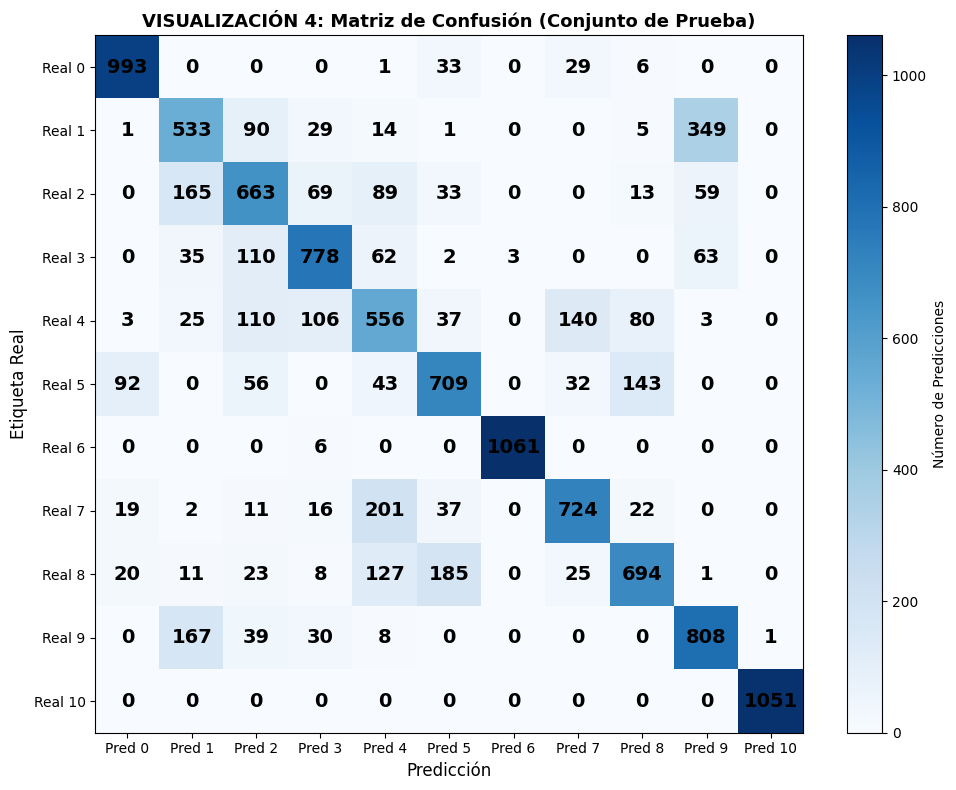

In [ ]:
# Visualizar matriz de confusión
fig, ax = pyplot.subplots(figsize=(10, 8))
im = ax.imshow(cm, cmap='Blues', aspect='auto')

ax.set_xticks(range(num_labels))
ax.set_yticks(range(num_labels))
ax.set_xticklabels([f'Pred {i}' for i in range(num_labels)])
ax.set_yticklabels([f'Real {i}' for i in range(num_labels)])

for i in range(num_labels):
    for j in range(num_labels):
        text = ax.text(j, i, int(cm[i, j]),
                       ha="center", va="center", color="black", fontsize=14, fontweight='bold')

ax.set_ylabel('Etiqueta Real', fontsize=12)
ax.set_xlabel('Predicción', fontsize=12)
ax.set_title('VISUALIZACIÓN 4: Matriz de Confusión (Conjunto de Prueba)', fontsize=13, fontweight='bold')
fig.colorbar(im, ax=ax, label='Número de Predicciones')
pyplot.tight_layout()
pyplot.show()

## 11. Gráficos de Convergencia

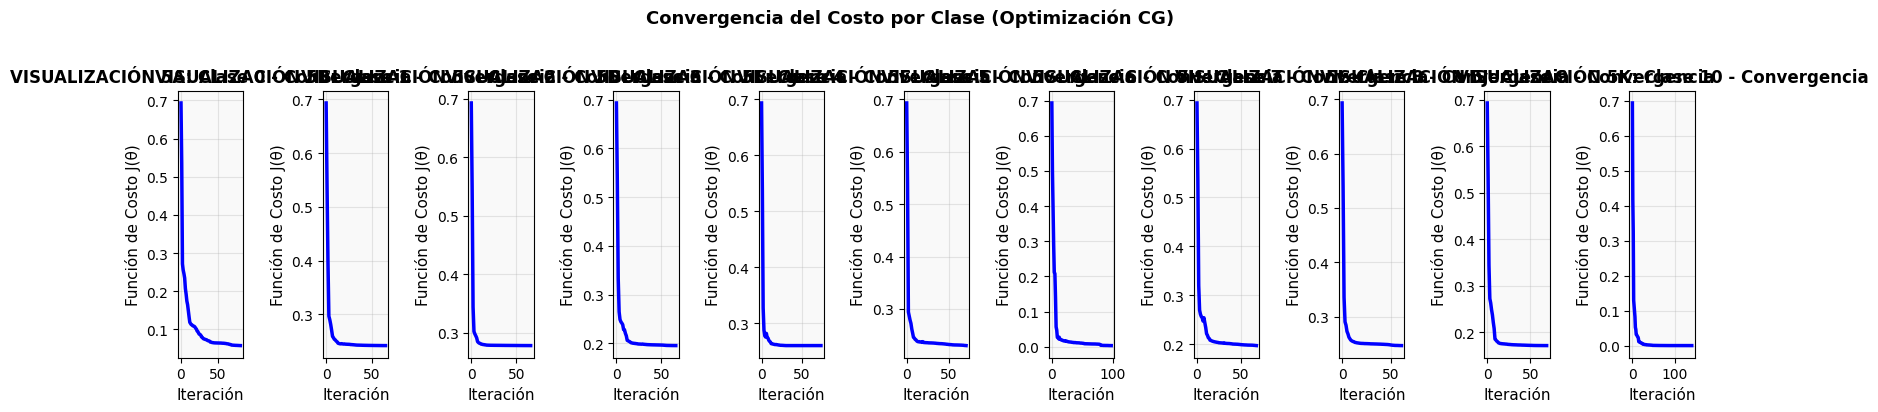

In [ ]:
# Gráfica de convergencia individual para cada clase
fig, axes = pyplot.subplots(1, num_labels, figsize=(16, 4))

if num_labels == 1:
    axes = [axes]

for c in range(num_labels):
    ax = axes[c]
    ax.plot(cost_history[c], 'b-', linewidth=2.5)
    ax.set_xlabel('Iteración', fontsize=11)
    ax.set_ylabel('Función de Costo J(θ)', fontsize=11)
    ax.set_title(f'VISUALIZACIÓN 5{chr(64+c+1)}: Clase {c} - Convergencia', fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.3)
    ax.set_facecolor('#f9f9f9')

pyplot.suptitle('Convergencia del Costo por Clase (Optimización CG)', fontsize=13, fontweight='bold', y=1.02)
pyplot.tight_layout()
pyplot.show()

In [ ]:
print(f"\n{'='*60}")
print(f"RESUMEN FINAL DEL MODELO")
print(f"{'='*60}")
print(f"Total de características: {n}")
print(f"Total de ejemplos: {m}")
print(f"Ejemplos entrenamiento: {m_train}")
print(f"Ejemplos prueba: {m_test}")
print(f"\nNúmero de clasificadores (One-vs-All): {num_labels}")
print(f"Parámetro de regularización (λ): {lambda_reg}")
print(f"\nDimensión de θ por clasificador: {n + 1}")
print(f"\nEXACTITUD FINAL EN CONJUNTO DE PRUEBA: {accuracy*100:.2f}%")
print(f"{'='*60}")


RESUMEN FINAL DEL MODELO
Total de características: 48
Total de ejemplos: 58300
Ejemplos entrenamiento: 46640
Ejemplos prueba: 11660

Número de clasificadores (One-vs-All): 11
Parámetro de regularización (λ): 1.0

Dimensión de θ por clasificador: 49

EXACTITUD FINAL EN CONJUNTO DE PRUEBA: 73.50%
